# Cl$_2$ energy error vs ground state

Log-scale plot of absolute energy error $|\Delta E|$ in milli-Hartree (mEh) vs bond length, with a green chemical-accuracy band ($1.6\,\mathrm{mEh} \approx 1\,\mathrm{kcal/mol}$):

1. **|VQE − GS|**: best REM+CF within 15 iterations vs exact ground state
2. **|HF − GS|**: Hartree–Fock vs exact ground state

- **HF / GS**: `Pauli_Ham/Cl2_bond_scan_summary.txt`
- **Best VQE**: `data/shots_<N>/Cl2_bond_*/vqe_results.json` → `min(rem_cf_eh)` over `energy_curves` (≤ 15 iters)

In [1]:
from __future__ import annotations

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np

HERE = Path(".").resolve()
PAULI_HAM = HERE / "Pauli_Ham"
SUMMARY = PAULI_HAM / "Cl2_bond_scan_summary.txt"

# Prefer data/ (current export path); fall back to cloud_data/ if present.
_candidates = [HERE / "data", HERE / "cloud_data"]
DATA_ROOT = next((p for p in _candidates if p.is_dir()), _candidates[0])

shots = 8192  # e.g. 8192 -> data/shots_8192
MIN_BOND = 1.6
MAX_ITERS = 15

VQE_COLOR = "#c0392b"
HF_COLOR = "#1f4e79"
CHEM_ACC_HA = 1.6e-3  # ≈ 1 kcal/mol
FACE = "#eef6e4"
CHEM_FACE = "#7fbf7f"

print(f"DATA_ROOT: {DATA_ROOT}")
print(f"shots: {shots}")
print(f"summary: {SUMMARY}")

DATA_ROOT: /Users/zacharyhe/cross_chips_sim/June_main/export2cloud/data
shots: 8192
summary: /Users/zacharyhe/cross_chips_sim/June_main/export2cloud/Pauli_Ham/Cl2_bond_scan_summary.txt


In [2]:
def load_cl2_summary(path: Path, min_bond: float | None = None):
    """Load bond, E_HF, E_GS from Cl2_bond_scan_summary.txt."""
    bonds, e_hf, e_gs = [], [], []
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#") or line.startswith("bond_"):
                continue
            parts = line.split("\t")
            if len(parts) < 3 or not parts[2]:
                continue
            bonds.append(float(parts[0]))
            e_hf.append(float(parts[1]))
            e_gs.append(float(parts[2]))
    bonds = np.asarray(bonds)
    e_hf = np.asarray(e_hf)
    e_gs = np.asarray(e_gs)
    if min_bond is not None:
        mask = bonds >= min_bond
        bonds, e_hf, e_gs = bonds[mask], e_hf[mask], e_gs[mask]
    return bonds, e_hf, e_gs


def load_best_vqe_energy(run_dir: Path, max_iters: int = MAX_ITERS) -> float | None:
    """Lowest REM+CF energy within the first max_iters VQE iterations.

    Prefers vqe_results.json energy_curves; falls back to E_best / best_E
    when the run completed with max_iters matching.
    """
    results_path = run_dir / "vqe_results.json"
    if results_path.is_file():
        data = json.loads(results_path.read_text(encoding="utf-8"))
        curves = data.get("energy_curves") or []
        rem = [
            float(c["rem_cf_eh"])
            for c in curves
            if c.get("rem_cf_eh") is not None and int(c.get("iter", 0)) <= max_iters
        ]
        if rem:
            return float(min(rem))
        if data.get("E_best") is not None:
            return float(data["E_best"])

    progress_path = run_dir / "vqe_progress.json"
    if progress_path.is_file():
        data = json.loads(progress_path.read_text(encoding="utf-8"))
        if data.get("best_E") is not None:
            return float(data["best_E"])
    return None


def load_cl2_vqe_curve(shots_dir: Path, min_bond: float | None = None):
    """Collect (bond, best_E) for every Cl2_bond_* run under shots_dir."""
    bonds, e_vqe = [], []
    for run_dir in sorted(shots_dir.glob("Cl2_bond_*")):
        if not run_dir.is_dir():
            continue
        try:
            bond = float(run_dir.name.split("_bond_")[1])
        except (IndexError, ValueError):
            continue
        if min_bond is not None and bond < min_bond:
            continue
        e = load_best_vqe_energy(run_dir)
        if e is None:
            print(f"skip (no VQE energy): {run_dir.name}")
            continue
        bonds.append(bond)
        e_vqe.append(e)
    order = np.argsort(bonds)
    return np.asarray(bonds)[order], np.asarray(e_vqe)[order]


bonds, e_hf, e_gs = load_cl2_summary(SUMMARY, min_bond=MIN_BOND)
gs_by_bond = {float(b): float(e) for b, e in zip(bonds, e_gs)}
hf_err_ha = np.abs(e_hf - e_gs)

SHOTS_DIR = DATA_ROOT / f"shots_{shots}"
if not SHOTS_DIR.is_dir():
    raise FileNotFoundError(f"Shots directory not found: {SHOTS_DIR}")

bonds_vqe, e_vqe = load_cl2_vqe_curve(SHOTS_DIR, min_bond=MIN_BOND)

# Align VQE with GS at the same bond lengths.
vqe_bonds, vqe_err_ha = [], []
for b, e in zip(bonds_vqe, e_vqe):
    key = float(b)
    if key not in gs_by_bond:
        # tolerate 1.8 vs 1.80 float keys
        matches = [k for k in gs_by_bond if abs(k - key) < 1e-9]
        if not matches:
            print(f"skip (no GS reference): Cl2_bond_{b:.1f}")
            continue
        key = matches[0]
    vqe_bonds.append(b)
    vqe_err_ha.append(abs(e - gs_by_bond[key]))

vqe_bonds = np.asarray(vqe_bonds)
vqe_err_ha = np.asarray(vqe_err_ha)

print(f"|HF−GS| bonds ({len(bonds)}): {bonds.tolist()}")
print(f"|VQE−GS| bonds ({len(vqe_bonds)}): {vqe_bonds.tolist()}")
print(f"{'bond':>6}  {'|HF−GS| (Ha)':>14}  {'|VQE−GS| (Ha)':>14}")
vqe_map = {float(b): e for b, e in zip(vqe_bonds, vqe_err_ha)}
for b, dhf in zip(bonds, hf_err_ha):
    dvqe = vqe_map.get(float(b))
    if dvqe is None:
        matches = [k for k in vqe_map if abs(k - float(b)) < 1e-9]
        dvqe = vqe_map[matches[0]] if matches else None
    vqe_s = f"{dvqe:14.6e}" if dvqe is not None else f"{'—':>14}"
    print(f"{b:6.1f}  {dhf:14.6e}  {vqe_s}")

|HF−GS| bonds (8): [1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0]
|VQE−GS| bonds (7): [1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0]
  bond    |HF−GS| (Ha)   |VQE−GS| (Ha)
   1.6    1.133963e-02               —
   1.8    1.693703e-02    1.733809e-03
   2.0    2.588604e-02    1.147669e-02
   2.2    3.898169e-02    1.065961e-02
   2.4    5.673078e-02    8.081275e-03
   2.6    7.884019e-02    3.457968e-02
   2.8    1.037476e-01    6.977215e-02
   3.0    1.289731e-01    6.903826e-02


Wrote /Users/zacharyhe/cross_chips_sim/June_main/export2cloud/cl2_vqe_energy.png


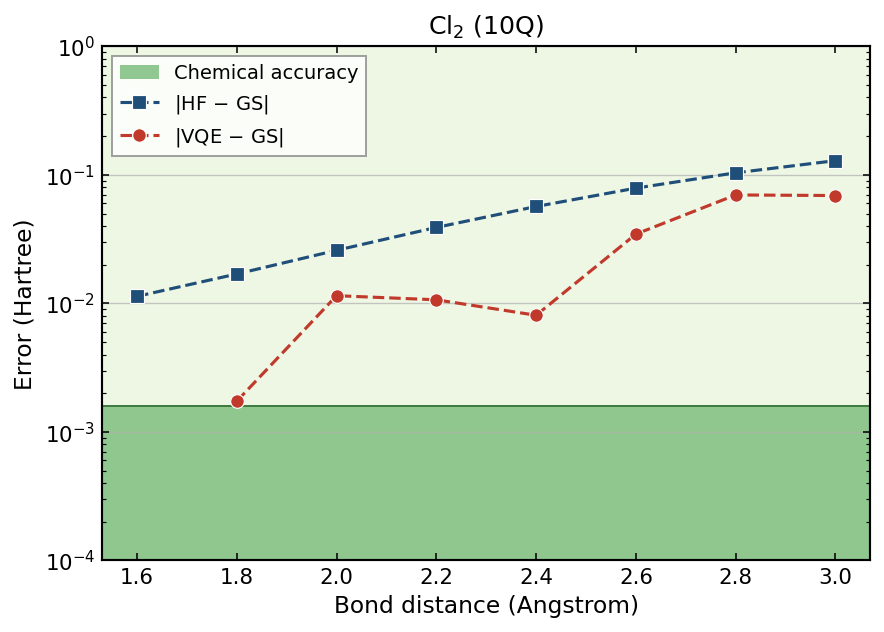

In [3]:
from matplotlib.ticker import LogLocator, NullFormatter

plt.rcParams.update({
    "figure.dpi": 140,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
})

fig, ax = plt.subplots(figsize=(6.2, 4.4), constrained_layout=True)
ax.set_facecolor(FACE)

y_all = np.concatenate([hf_err_ha, vqe_err_ha]) if len(vqe_err_ha) else hf_err_ha
# Match reference-style Hartree log axis (powers of 10).
ymin = 1e-4
ymax = 10 ** np.ceil(np.log10(float(np.max(y_all)) * 1.2))

# Chemical-accuracy band (green), then curves on top.
ax.axhspan(ymin, CHEM_ACC_HA, facecolor=CHEM_FACE, alpha=0.85, zorder=0, label="Chemical accuracy")
ax.axhline(CHEM_ACC_HA, color="#3d7a3d", lw=1.0, zorder=1)

ax.plot(
    bonds,
    hf_err_ha,
    color=HF_COLOR,
    lw=1.6,
    ls="--",
    marker="s",
    ms=7,
    markerfacecolor=HF_COLOR,
    markeredgecolor="white",
    markeredgewidth=0.6,
    label=r"$|$HF $-$ GS$|$",
    zorder=3,
)
ax.plot(
    vqe_bonds,
    vqe_err_ha,
    color=VQE_COLOR,
    lw=1.6,
    ls="--",
    marker="o",
    ms=7,
    markerfacecolor=VQE_COLOR,
    markeredgecolor="white",
    markeredgewidth=0.6,
    label=r"$|$VQE $-$ GS$|$",
    zorder=4,
)

ax.set_yscale("log")
ax.set_ylim(ymin, ymax)
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=12))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
ax.yaxis.set_minor_formatter(NullFormatter())

ax.set_title(r"Cl$_2$ (10Q)")
ax.set_xlabel("Bond distance (Angstrom)")
ax.set_ylabel("Error (Hartree)")
ax.grid(True, axis="y", which="major", color="#b0b0b0", lw=0.7, alpha=0.7, zorder=1)
ax.tick_params(direction="in", top=True, right=True, which="both")
for spine in ax.spines.values():
    spine.set_linewidth(1.1)
ax.legend(frameon=True, fancybox=False, edgecolor="#888888", loc="upper left")

out = HERE / "cl2_vqe_energy.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"Wrote {out}")
plt.show()